# F1 – Design to Survive
## EDA: Pit Stops & Däckstrategi — Monza

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("Imports klara!")

Imports klara!


## 1. Läs data från DuckDB

In [2]:
con = duckdb.connect("../data/pitstops_monza.duckdb")

stints_df  = con.execute("SELECT * FROM stints").df()
drivers_df = con.execute("SELECT * FROM drivers").df()
stints_df["stint_length"] = stints_df["lap_end"] - stints_df["lap_start"] + 1

print(f"Laddad: {len(stints_df)} stints, {len(drivers_df)} förar-poster")

Laddad: 134 stints, 60 förar-poster


## 2. Utforska datan

In [3]:
con.execute("SHOW TABLES").df()

,name
0,drivers
1,stints


In [4]:
con.execute("SELECT * FROM stints LIMIT 10").df()

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start,year,stint_length
0,1218,9157,1,20,1.0,12.0,HARD,4,2023,12.0
1,1218,9157,1,40,1.0,13.0,MEDIUM,3,2023,13.0
2,1218,9157,1,1,1.0,20.0,MEDIUM,0,2023,20.0
3,1218,9157,1,16,1.0,20.0,MEDIUM,0,2023,20.0
4,1218,9157,1,22,NaN,NaN,MEDIUM,3,2023,NaN
5,1218,9157,1,11,1.0,21.0,MEDIUM,0,2023,21.0
6,1218,9157,1,31,1.0,24.0,MEDIUM,0,2023,24.0
7,1218,9157,1,77,1.0,25.0,HARD,3,2023,25.0
8,1218,9157,1,63,1.0,19.0,MEDIUM,0,2023,19.0
9,1218,9157,1,18,1.0,20.0,MEDIUM,0,2023,20.0


In [5]:
con.execute("SELECT * FROM drivers LIMIT 10").df()

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code,year
0,1218,9157,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://www.formula1.com/content/dam/fom-websi...,NED,2023
1,1218,9157,2,L SARGEANT,Logan SARGEANT,SAR,Williams,37BEDD,Logan,Sargeant,https://www.formula1.com/content/dam/fom-websi...,USA,2023
2,1218,9157,4,L NORRIS,Lando NORRIS,NOR,McLaren,F58020,Lando,Norris,https://www.formula1.com/content/dam/fom-websi...,GBR,2023
3,1218,9157,10,P GASLY,Pierre GASLY,GAS,Alpine,2293D1,Pierre,Gasly,https://www.formula1.com/content/dam/fom-websi...,FRA,2023
4,1218,9157,11,S PEREZ,Sergio PEREZ,PER,Red Bull Racing,3671C6,Sergio,Perez,https://www.formula1.com/content/dam/fom-websi...,MEX,2023
5,1218,9157,14,F ALONSO,Fernando ALONSO,ALO,Aston Martin,358C75,Fernando,Alonso,https://www.formula1.com/content/dam/fom-websi...,ESP,2023
6,1218,9157,16,C LECLERC,Charles LECLERC,LEC,Ferrari,F91536,Charles,Leclerc,https://www.formula1.com/content/dam/fom-websi...,MON,2023
7,1218,9157,18,L STROLL,Lance STROLL,STR,Aston Martin,358C75,Lance,Stroll,https://www.formula1.com/content/dam/fom-websi...,CAN,2023
8,1218,9157,20,K MAGNUSSEN,Kevin MAGNUSSEN,MAG,Haas F1 Team,B6BABD,Kevin,Magnussen,https://www.formula1.com/content/dam/fom-websi...,DEN,2023
9,1218,9157,22,Y TSUNODA,Yuki TSUNODA,TSU,AlphaTauri,5E8FAA,Yuki,Tsunoda,https://www.formula1.com/content/dam/fom-websi...,JPN,2023


## 3. Pandas EDA

##### Standard deviation — it measures how spread out the values are from the mean.
For HARD tyres, mean = 26.5 and std = 10.0, meaning most stints fell roughly between 16 and 37 laps. A high std means inconsistent stint lengths; a low std means most drivers did similar-length stints.

In [6]:
# Summary statistics (count, mean, std, min, max etc.) per tyre compound
print("Stint-längd per däcktyp:")
stints_df.groupby("compound")["stint_length"].describe().round(1)

Stint-längd per däcktyp:


,count,mean,std,min,25%,50%,75%,max
compound,,,,,,,,
HARD,66.0,26.5,10.0,4.0,20.0,25.0,33.0,51.0
MEDIUM,60.0,19.2,8.6,1.0,14.0,18.5,21.0,46.0
SOFT,7.0,4.7,3.2,1.0,2.5,3.0,7.5,9.0


In [7]:
# Number of pit stops per driver per year (max stint number - 1 = pit stops)
pit_counts = (stints_df.groupby(["year", "driver_number"])["stint_number"]
              .max().sub(1).reset_index(name="pit_stops"))
print("Pit stops per år:")
pit_counts.groupby("year")["pit_stops"].describe().round(1)

Pit stops per år:


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2023,20.0,1.2,0.6,0.0,1.0,1.0,2.0,2.0
2024,20.0,1.5,0.7,0.0,1.0,1.5,2.0,3.0
2025,20.0,1.0,0.2,0.0,1.0,1.0,1.0,1.0


In [8]:
# Tyre compound usage as percentages per year
print("Däckfördelning per år (%):")
stints_df.groupby("year")["compound"].value_counts(normalize=True).mul(100).round(1)

Däckfördelning per år (%):


year  compound
2023  MEDIUM      57.8
      HARD        42.2
2024  HARD        60.0
      MEDIUM      38.0
      SOFT         2.0
2025  HARD        43.6
      MEDIUM      41.0
      SOFT        15.4
Name: proportion, dtype: float64

## 4. DuckDB EDA

In [9]:
# Average stint length and count per year and compound
con.execute("""
    SELECT year, compound,
           ROUND(AVG(lap_end - lap_start + 1), 1) AS avg_varv,
           COUNT(*) AS antal_stints
    FROM stints
    GROUP BY year, compound
    ORDER BY year, avg_varv DESC
""").df()

,year,compound,avg_varv,antal_stints
0,2023,HARD,26.5,19
1,2023,MEDIUM,18.0,26
2,2024,HARD,24.4,30
3,2024,MEDIUM,14.4,19
4,2024,SOFT,2.0,1
5,2025,HARD,30.4,17
6,2025,MEDIUM,26.8,16
7,2025,SOFT,5.2,6


In [10]:
# Which tyre compound do drivers start on most often?
con.execute("""
    SELECT year, compound, COUNT(*) AS freq
    FROM stints
    WHERE stint_number = 1
    GROUP BY year, compound
    ORDER BY year, freq DESC
""").df()

,year,compound,freq
0,2023,MEDIUM,17
1,2023,HARD,3
2,2024,MEDIUM,14
3,2024,HARD,6
4,2025,MEDIUM,14
5,2025,HARD,5
6,2025,SOFT,1


In [11]:
# Top 3 most-pitted drivers per year
con.execute("""
    SELECT year, driver_number,
           MAX(stint_number) - 1 AS pit_stops
    FROM stints
    GROUP BY year, driver_number
    ORDER BY year, pit_stops DESC
""").df().groupby("year").head(3)

,year,driver_number,pit_stops
0,2023,20,2
1,2023,81,2
2,2023,40,2
20,2024,18,3
21,2024,1,2
22,2024,81,2
40,2025,12,1
41,2025,4,1
42,2025,5,1


## 5. Storytelling-grafer

In [12]:
# Dark F1-themed color palette
BG    = "#0D0D0D" # background
CARD  = "#1A1A1A" # chart area
MUTED = "#888888" # secondary text / grid
WHITE = "#FFFFFF"

# Official Pirelli tyre colors
COMPOUND_COLORS = {
    "SOFT":   "#E8002D",
    "MEDIUM": "#FFD700",
    "HARD":   "#FFFFFF",
    "INTER":  "#39B54A",
    "WET":    "#0067FF",
}

# Apply dark theme globally to all matplotlib plots
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "axes.edgecolor": "#333333", "text.color": WHITE,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#222222", "font.family": "monospace",
})
print("Styling klar!")

Styling klar!


### Graf 1 — Däckstrategin på Monza 2025

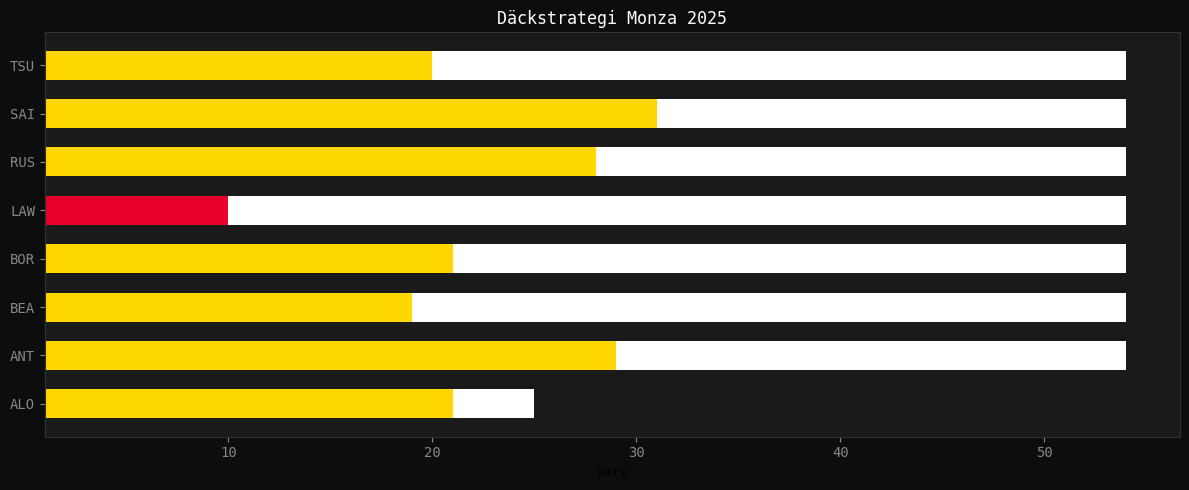

In [14]:
# Filter to most recent year
latest_year  = stints_df["year"].max()
race_stints  = stints_df[stints_df["year"] == latest_year].copy()
race_drivers = drivers_df[drivers_df["year"] == latest_year]

# Add driver abbreviations (e.g. "VER") to the stints data
merged = race_stints.merge(
    race_drivers[["driver_number", "name_acronym"]].drop_duplicates(),
    on="driver_number", how="left"
)
# Fallback to driver number if name is missing
merged["name_acronym"] = merged["name_acronym"].fillna(merged["driver_number"].astype(str))

# Keep only the 8 drivers with the most complete data
top8 = merged["driver_number"].value_counts().head(8).index
merged = merged[merged["driver_number"].isin(top8)]

# Sort drivers on Y-axis by number of stints
drivers_order = (merged.groupby("name_acronym")["stint_number"]
                 .max().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 5))

# Draw one bar per stint — position on X = lap number, width = stint length
for _, row in merged.iterrows():
    color = COMPOUND_COLORS.get(str(row["compound"]).upper(), "#555")
    width = row["lap_end"] - row["lap_start"] + 1  # +1 because both ends are inclusive
    y     = drivers_order.index(row["name_acronym"])
    ax.barh(y, width, left=row["lap_start"], color=color, height=0.6)

ax.set_yticks(range(len(drivers_order)))
ax.set_yticklabels(drivers_order)
ax.set_xlabel("Varv")
ax.set_title(f"Däckstrategi Monza {latest_year}")
ax.grid(False)

plt.tight_layout()
plt.savefig("output/pitstops_01_monza_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

### GRAF 2: När stannade förarna? Pit stop-varv på Monza 2025

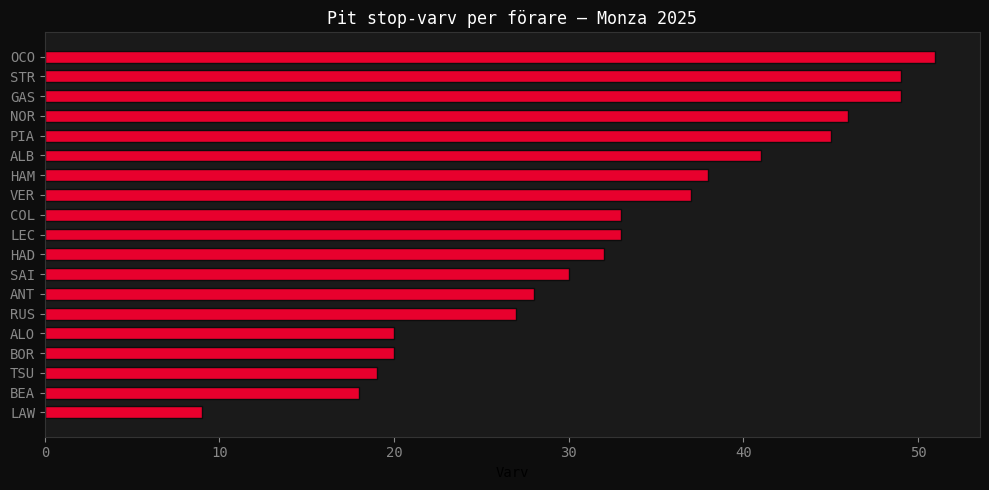

In [ ]:
# The pit stop happens on the last lap of each stint (except the final stint)
pit_laps = (
    stints_df[stints_df["year"] == latest_year]
    .groupby("driver_number")
    .apply(lambda x: x.sort_values("stint_number").iloc[:-1]["lap_end"])
    .reset_index(level=0)
    .rename(columns={"lap_end": "pit_lap"})
)

# Add driver names
pit_laps = pit_laps.merge(
    race_drivers[["driver_number", "name_acronym"]].drop_duplicates(),
    on="driver_number", how="left"
)
pit_laps = pit_laps.sort_values("pit_lap")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(pit_laps["name_acronym"], pit_laps["pit_lap"],
        color="#E8002D", edgecolor=BG, height=0.6)

ax.set_xlabel("Varv")
ax.set_title(f"Pit stop-varv per förare — Monza {latest_year}")
ax.grid(False)

plt.tight_layout()
plt.savefig("output/pitstops_02_monza_pitstops.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
con.checkpoint()
con.close()
print("Klar!")

Klar!
